In [1]:
main_llm_dir = '/Users/jnaiman/Downloads/tmp/iConf2025/visual_qa_multipanel/LMM_outputs/'

# full baseline data stored
dir_jsons = '/Users/jnaiman/Downloads/tmp/iConf2025/visual_qa_multipanel/jsons/'

save_fig_dir = '/Users/jnaiman/Dropbox/Paper_iConf2025/figures/'

In [2]:
from glob import glob
import pickle
import pandas as pd
import json
from copy import deepcopy
import numpy as np
import os
import matplotlib.pyplot as plt
from Levenshtein import distance as levenshtein_distance # Assuming you have python-Levenshtein installed

# debug
from importlib import reload

import seaborn as sns
import numpy as np

In [3]:
dirs_tmp = glob(main_llm_dir + '*')
dirs_tmp

['/Users/jnaiman/Downloads/tmp/iConf2025/visual_qa_multipanel/LMM_outputs/gemini_api_2.5',
 '/Users/jnaiman/Downloads/tmp/iConf2025/visual_qa_multipanel/LMM_outputs/claude_api',
 '/Users/jnaiman/Downloads/tmp/iConf2025/visual_qa_multipanel/LMM_outputs/gemini_api_1.5',
 '/Users/jnaiman/Downloads/tmp/iConf2025/visual_qa_multipanel/LMM_outputs/chatgpt_api']

In [4]:
dirnames = []

dn_ignore = 'gemini_2.5'

dirs = []
for d in dirs_tmp:
    dn = d.split('/')[-1].replace('_api','')
    if dn not in dn_ignore:
        dirnames.append(dn)
        dirs.append(d)

dirnames

['claude', 'gemini_1.5', 'chatgpt']

In [5]:
# find total overlap of files
files_parsed = []
for d in dirs:
    files = glob(d + '/*.pickle')
    for f in files:
        files_parsed.append(f.split('/')[-1])
files_parsed1 = list(set(files_parsed))
# now check all exist
files_parsed = []
for f in files_parsed1:
    exists = True
    for d in dirs:
        if not os.path.exists(d + '/' + f):
            exists = False
    if exists:
        files_parsed.append(f)

print("there are:", len(files_parsed), 'overlapping files so far')

there are: 200 overlapping files so far


In [6]:
import utils.parse_lmm_output_utils
reload(utils.parse_lmm_output_utils)

from utils.parse_lmm_output_utils import parse_json_files

df = parse_json_files(dirnames, dirs, files_parsed, dir_jsons, 
                     verbose=True)


*********** claude ****************

----------- Picture162.pickle ------------
----------- Picture30.pickle ------------
----------- Picture148.pickle ------------
----------- Picture49.pickle ------------
----------- Picture102.pickle ------------
----------- Picture94.pickle ------------
----------- Picture44.pickle ------------
----------- Picture155.pickle ------------
----------- Picture164.pickle ------------
----------- Picture124.pickle ------------
----------- Picture12.pickle ------------
----------- Picture103.pickle ------------
----------- Picture27.pickle ------------
----------- Picture126.pickle ------------
----------- Picture5.pickle ------------
----------- Picture165.pickle ------------
----------- Picture73.pickle ------------
----------- Picture70.pickle ------------
[ERROR]: json decode error --  Expecting value: line 1 column 1329 (char 1328)

----------- Picture75.pickle ------------
----------- Picture46.pickle ------------
----------- Picture48.pickle -----

In [7]:
df.head()

,image id,plot number,plot type,question,use list,model,model id,LMM Answer,GT Answer,Level,Level Type
0,Picture162,NaN,None,How many panels are in this figure?,False,claude,claude-sonnet-4-20250514,"{'nrows': 2, 'ncols': 4}","{'nrows': 2, 'ncols': 4}",Level 1,Figure-level questions
1,Picture162,NaN,None,What is the plot style used in this figure?,False,claude,claude-sonnet-4-20250514,{'plot style': 'ggplot'},{'plot style': 'seaborn-v0_8-notebook'},Level 1,Figure-level questions
2,Picture162,NaN,None,What is the colormap that was used in this fig...,False,claude,claude-sonnet-4-20250514,{'colormap': 'rainbow'},{'colormap': 'gray'},Level 1,Figure-level questions
3,Picture162,NaN,None,What is the aspect ratio of this figure?,False,claude,claude-sonnet-4-20250514,{'aspect ratio': 1.0},{'aspect ratio': 0.516973126799935},Level 1,Figure-level questions
4,Picture162,NaN,None,What are the titles for each figure panel?,False,claude,claude-sonnet-4-20250514,"{'title': ['INTERVALS', 'Vicinity Static Look ...","{'title': ['INTERVALS', '', 'Vicinity Static L...",Level 1,Figure-level questions


In [8]:
import utils.parse_lmm_output_utils
reload(utils.parse_lmm_output_utils)

from utils.parse_lmm_output_utils import get_lmm_gt

df_question_tags = {}
for t in ['tag', 'question', 'Level', 'Type']:
    df_question_tags[t] = []

## Figure level, vs # panels

In [9]:
# figure-level questions
questions_figure = [
    {'tag':'# panels', 'question':'How many panels are in this figure?', 'type':'special'},
    {'tag':'plot type', 'question':'What is the plot style used in this figure?', 'type':'binary string'},
    {'tag':'colormap', 'question':'What is the colormap that was used in this figure?', 'type':'binary string'},
    #{'tag':'aspect ratio', 'question':'What is the aspect ratio of this figure?', 'type':'float'},
    {'tag':'titles', 'question': 'What are the titles for each figure panel?', 'type':'string list'},
]

df_F_question_tags = {}
for k,v in df_question_tags.items():
    df_F_question_tags[k] = []

use_float_average = True # if so, will divide floats by average gt

dfplot = {'Tag':[]}

# fill level and level types
for iq,q in enumerate(questions_figure):
    if iq > 0: continue
    dfplot[q['tag'] + ' GT'] = []
    dfsub = df[df['question']==q['question']]
    for model in dfsub['model'].unique():
        dfplot[model + ' ' + q['tag']] = []
        dfsub2 = dfsub[dfsub['model']==model]
        if q['tag'] == '# panels': # something special
            gt = []
            for g in dfsub2['GT Answer'].values:
                gt.append(g['nrows']*g['ncols'])
            lmm = []
            for l in dfsub2['LMM Answer'].values:
                lmm.append(l['nrows']*l['ncols'])
            # fill
            dfplot[model + ' ' + q['tag']].extend(lmm)
    dfplot[q['tag'] + ' GT'].extend(gt)
    dfplot['Tag'].extend([q['tag']]*len(gt))
    #df_question_tags['Level'].append(np.unique(dfsub['Level'])[0])

# now add other questions
for iq,q in enumerate(questions_figure):
    if iq < 1: continue # don't re-do add of panels
    dfsub = df[df['question']==q['question']]
    #df_question_tags['Level'].append(np.unique(dfsub['Level'])[0])
    for model in dfsub['model'].unique():
        dfplot[model + ' ' + q['tag']] = []
        dfsub2 = dfsub[dfsub['model']==model]    
        if q['type'] == 'binary string': 
            gt, lmm = get_lmm_gt(dfsub2, q['type'])
            calc = []
            for g,l in zip(gt,lmm):
                if g == l:
                    calc.append(1)
                else:
                    calc.append(0)
            # fill
            dfplot[model + ' ' + q['tag']].extend(calc)

        elif q['type'] == 'string list':
            # loop over every figure
            calc = [] # normalized distance
            #l_tot = []
            #total_d = 0; total_l = 0
            for iq in range(len(dfsub2)): # over each image
                dfsub22 = dfsub2.iloc[iq]
                gt, lmm = get_lmm_gt(dfsub22.to_frame().T, q['type'], verbose=False)
                #lmm_tot.extend(lmm)
                # get distance/length
                total_d = 0; total_l = 0
                for g, l in zip(gt,lmm): # over all titles in each image
                    d = levenshtein_distance(g,l)
                    total_d += d
                    if len(g) > 0:
                        total_l += len(g)
                    else:
                        total_l += len(l)
                if total_l > 0:
                    calc.append(total_d*1.0/total_l)
                else:
                    calc.append(0)
            # fill
            dfplot[model + ' ' + q['tag']].extend((1.0-np.array(calc)).tolist()) # 1 - so closer to other acc


dfplot = pd.DataFrame(dfplot)

# also track questions
for qa in questions_figure:
    dfsub = df[df['question']==qa['question']]
    df_F_question_tags['tag'].append(qa['tag'].replace('#', '\\#'))
    df_F_question_tags['question'].append(qa['question'].replace('#', '\\#'))
    level = np.unique(dfsub['Level'])[0].split('Level')[-1].replace(' ','')
    df_F_question_tags['Level'].append(level)
    ltype = np.unique(dfsub['Level Type'])[0].split('-level questions')[0]
    df_F_question_tags['Type'].append(ltype)

In [10]:
df_F_question_tags

{'tag': ['\\# panels', 'plot type', 'colormap', 'titles'],
 'question': ['How many panels are in this figure?',
  'What is the plot style used in this figure?',
  'What is the colormap that was used in this figure?',
  'What are the titles for each figure panel?'],
 'Level': ['1', '1', '1', '1'],
 'Type': ['Figure', 'Figure', 'Figure', 'Figure']}

In [11]:
# for k,v in dfplot.items():
#     print(k, len(v))

In [12]:
dfplot

,Tag,# panels GT,claude # panels,gemini_1.5 # panels,chatgpt # panels,claude plot type,gemini_1.5 plot type,chatgpt plot type,claude colormap,gemini_1.5 colormap,chatgpt colormap,claude titles,gemini_1.5 titles,chatgpt titles
0,# panels,8,8,8,8,0,0,0,0,0,0,0.053892,0.558824,0.088235
1,# panels,1,1,1,1,0,0,0,0,0,0,1.000000,1.000000,1.000000
2,# panels,1,1,1,1,0,0,0,0,0,0,1.000000,0.000000,1.000000
3,# panels,3,3,15,3,0,0,0,0,0,1,0.000000,0.211765,0.482993
4,# panels,1,1,1,2,0,0,0,1,1,0,0.708333,0.687500,0.812500
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
195,# panels,1,1,1,1,0,0,0,0,0,0,1.000000,1.000000,1.000000
196,# panels,8,8,8,8,0,0,0,0,0,0,0.488372,0.037267,0.165680
197,# panels,4,4,4,4,0,0,0,0,1,0,0.833333,-0.311688,0.428571
198,# panels,6,6,8,6,0,0,0,0,1,0,0.375000,0.034247,0.890625


In [13]:
dfpsort = dfplot['# panels GT'].value_counts().sort_index()
dfpsort

# panels GT
1     98
2      8
3     10
4      7
5      9
6     11
8     16
9     13
12    12
15     7
16     4
20     3
24     1
25     1
Name: count, dtype: int64

In [14]:
# for plotting, only take ones where count = X or more
count_cut = 5
panels_cut = dfpsort[dfpsort >= count_cut].index
print('only these panels:', np.array(panels_cut.values))

dfcut = dfplot.copy()#[dfplot[dfplot['# panels GT']] >= panels_cut.max()]
dfcut = dfcut[dfcut['# panels GT'].isin(panels_cut)]
dfcut.head()

only these panels: [ 1  2  3  4  5  6  8  9 12 15]


,Tag,# panels GT,claude # panels,gemini_1.5 # panels,chatgpt # panels,claude plot type,gemini_1.5 plot type,chatgpt plot type,claude colormap,gemini_1.5 colormap,chatgpt colormap,claude titles,gemini_1.5 titles,chatgpt titles
0,# panels,8,8,8,8,0,0,0,0,0,0,0.053892,0.558824,0.088235
1,# panels,1,1,1,1,0,0,0,0,0,0,1.000000,1.000000,1.000000
2,# panels,1,1,1,1,0,0,0,0,0,0,1.000000,0.000000,1.000000
3,# panels,3,3,15,3,0,0,0,0,0,1,0.000000,0.211765,0.482993
4,# panels,1,1,1,2,0,0,0,1,1,0,0.708333,0.687500,0.812500


In [30]:
# For levels:
# Number of contour levels or values to draw contours at. 
# A vector argument must have increasing values in [0, 1]. 
# Levels correspond to iso-proportions of the density: 
# e.g., 20% of the probability mass will lie below the 
# contour drawn for 0.2. Only relevant with bivariate data.

# # Function to create jointplot-style contours on existing axes
# def add_contour_plot(ax, x_data, y_data, color, label, marker, levels=3):
#     """Add contour plot to existing axes"""
#     # Create a temporary figure for jointplot
#     temp_fig, temp_ax = plt.subplots(figsize=(6, 6))
    
#     # Create the jointplot
#     joint = sns.jointplot(x=x_data, y=y_data, kind='kde', 
#                          color=color, fill=False, ax=temp_ax, levels=levels)
    
#     # Extract contour data from the jointplot
#     # Get the KDE contours
#     kde_ax = joint.ax_joint
#     contours = kde_ax.collections
    
#     # Transfer contours to our main plot
#     for collection in contours:
#         paths = collection.get_paths()
#         for path in paths:
#             ax.add_patch(plt.Polygon(path.vertices, fill=False, 
#                                    edgecolor=color, linewidth=2, alpha=0.7))
    
#     # Add scatter points as well
#     ax.scatter(x_data, y_data, c=color, marker=marker, s=50, 
#               alpha=0.6, label=label, edgecolors='white', linewidth=0.5)
    
#     # Close temporary figure
#     plt.close(temp_fig)

# Alternative approach using seaborn's kdeplot directly
def add_kde_contours(ax, x_data, y_data, color, label, marker, marker_size, 
                     levels=3, alpha=0.5, plot_kde=True):
    """Add KDE contours directly using seaborn"""
    # Add contour lines
    if plot_kde:
        sns.kdeplot(x=x_data, y=y_data, ax=ax, color=color, 
                fill=False, alpha=alpha, linewidths=2, levels=levels)
    
    # Add scatter points
    ax.scatter(x_data, y_data, c=color, marker=marker, s=marker_size, 
              alpha=0.8, label=label, edgecolors='white', linewidth=0.5)

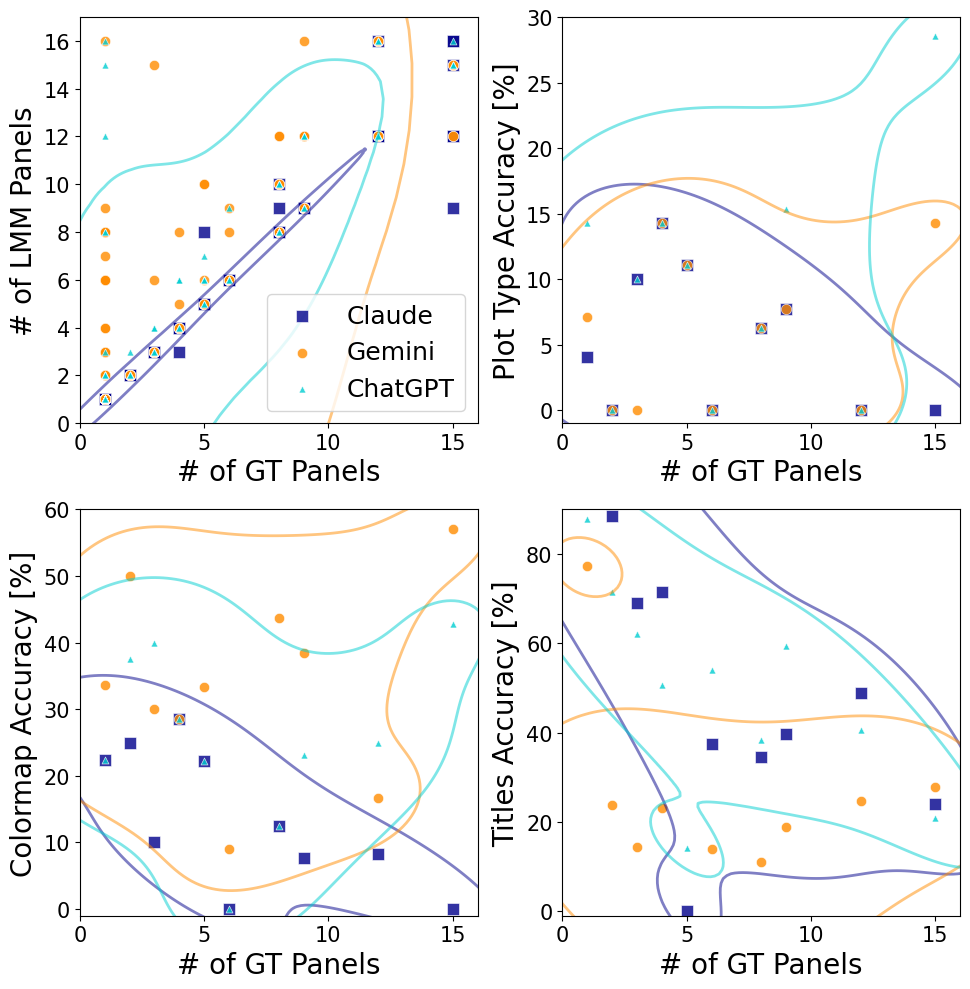

In [34]:
# Your existing parameters
base = 5
nx = 2; ny = 2
npanels = nx*ny

levels = [0.25]

plot_kde = True

fontsize = 20
tick_fontsize = 15
legend_fontsize = 18

marker_sizes = [85, 55, 25]
colors = ['darkblue', 'darkorange', 'darkturquoise']
labels = ['Claude', 'Gemini', 'ChatGPT']
marker_styles = ['s', 'o', '^']

binary_acc_as_per = True


# Create the main figure
fig, axes = plt.subplots(nx, ny, figsize=(base*2, base*2))
axes = axes.flatten()

# Define your data columns
xcolumn = '# panels GT'
panel_columns = ['claude # panels', 'gemini_1.5 # panels', 'chatgpt # panels']
plot_type_columns = ['claude plot type', 'gemini_1.5 plot type', 'chatgpt plot type']
colormap_columns = ['claude colormap', 'gemini_1.5 colormap', 'chatgpt colormap']
titles_columns = ['claude titles', 'gemini_1.5 titles', 'chatgpt titles']



####### Panel 1: # panels vs gt LMM # panels #####
iax = 0
yfudge = 2

for color, col, label, marker, ms in zip(colors, panel_columns, labels, marker_styles, marker_sizes):
    x_data = dfcut[xcolumn]
    y_data = dfcut[col]
    add_kde_contours(axes[iax], x_data, y_data, color, label, marker, ms, levels=levels, plot_kde=plot_kde)

axes[iax].set_ylim(dfcut[xcolumn].min()-yfudge, dfcut[xcolumn].max()+yfudge)
axes[iax].set_xlabel('# of GT Panels', fontsize=fontsize)
axes[iax].set_ylabel('# of LMM Panels', fontsize=fontsize)
axes[iax].legend(fontsize=legend_fontsize)

###### Panel 2: # panels vs LMM plot type guess ####
iax = 1
gb = dfcut.groupby('# panels GT')[plot_type_columns].mean().reset_index()

for color, col, label, marker, ms in zip(colors, plot_type_columns, labels, marker_styles, marker_sizes):
    x_data = gb[xcolumn]
    
    if not binary_acc_as_per:
        y_data = gb[col]
        div = ''
    else:
        y_data = gb[col] * 100.0
        div = ' [%]'
    
    add_kde_contours(axes[iax], x_data, y_data, color, label, marker, ms, levels=levels, plot_kde=plot_kde)

axes[iax].set_xlabel('# of GT Panels', fontsize=fontsize)
axes[iax].set_ylabel('Plot Type Accuracy'+div, fontsize=fontsize)

###### Panel 3: # panels vs LMM colormap guess ####
iax = 2
gb = dfcut.groupby('# panels GT')[colormap_columns].mean().reset_index()

for color, col, label, marker,ms in zip(colors, colormap_columns, labels, marker_styles, marker_sizes):
    x_data = gb[xcolumn]
    
    if not binary_acc_as_per:
        y_data = gb[col]
        div = ''
    else:
        y_data = gb[col] * 100.0
        div = ' [%]'
    
    add_kde_contours(axes[iax], x_data, y_data, color, label, marker, ms, levels=levels, plot_kde=plot_kde)

axes[iax].set_xlabel('# of GT Panels', fontsize=fontsize)
axes[iax].set_ylabel('Colormap Accuracy'+div, fontsize=fontsize)

###### Panel 4: # panels vs titles guess ####
iax = 3
gb = dfcut.groupby('# panels GT')[titles_columns].mean().reset_index()

for color, col, label, marker, ms in zip(colors, titles_columns, labels, marker_styles, marker_sizes):
    x_data = gb[xcolumn]
    
    if not binary_acc_as_per:
        y_data = gb[col]
        div = ''
    else:
        y_data = gb[col] * 100.0
        div = ' [%]'
    
    add_kde_contours(axes[iax], x_data, y_data, color, label, marker, ms, levels=levels, plot_kde=plot_kde)

axes[iax].set_xlabel('# of GT Panels', fontsize=fontsize)
axes[iax].set_ylabel('Titles Accuracy'+div, fontsize=fontsize)

# Set font sizes for all axes
for ax in axes:
    ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)
    legend = ax.get_legend()
    if legend is not None:
        ax.legend(fontsize=legend_fontsize)


xlim = [0,16]

ylims = [
    [0,17], # # of panels
    [-1, 30], # plot type accuracy
    [-1, 60], # colormap accuracy
    [-1, 90] # titles
]
for iax,ax in enumerate(axes):
    ax.set_ylim(ylims[iax])
    # set x-lim
    ax.set_xlim(xlim)

# Adjust layout and save
fig.tight_layout()
fig.savefig(save_fig_dir + 'figureLevel_models_vs_npanels_jointplot.pdf')
plt.show()

# ----------- HERE -----------

In [16]:
dfplot['# panels GT'].value_counts().sort_index()

# panels GT
1     98
2      8
3     10
4      7
5      9
6     11
8     16
9     13
12    12
15     7
16     4
20     3
24     1
25     1
Name: count, dtype: int64

In [17]:
dfplot['# panels GT']

0      12
1       1
2      12
3       1
4       1
       ..
195     9
196    12
197     1
198     5
199     9
Name: # panels GT, Length: 200, dtype: int64

## Plot-level, Level 1

In [18]:
# Level 1
df[(df['Level Type']=='Plot-level questions') & (df['Level'] == 'Level 1')]['question'].unique()

array(['What are the matplotlib linestyles in this figure panel?',
       'How many bars are there in the specified figure panel?',
       'How many lines are there in the specified figure panel?',
       'How many scatter points are there in the specified figure panel?'],
      dtype=object)

In [19]:
def track_questions(questions_figure, df, ignore_special = False):
    df_F_question_tags = {}
    for k,v in df_question_tags.items():
        df_F_question_tags[k] = []
    # also track questions
    for qa in questions_figure:
        if ignore_special and qa['type'] == 'special':
            continue
        dfsub = df[df['question']==qa['question']]
        df_F_question_tags['tag'].append(qa['tag'].replace('#', '\\#'))
        df_F_question_tags['question'].append(qa['question'].replace('#', '\\#'))
        level = np.unique(dfsub['Level'])[0].split('Level')[-1].replace(' ','')
        df_F_question_tags['Level'].append(level)
        ltype = np.unique(dfsub['Level Type'])[0].split('-level questions')[0]
        df_F_question_tags['Type'].append(ltype)
    return df_F_question_tags

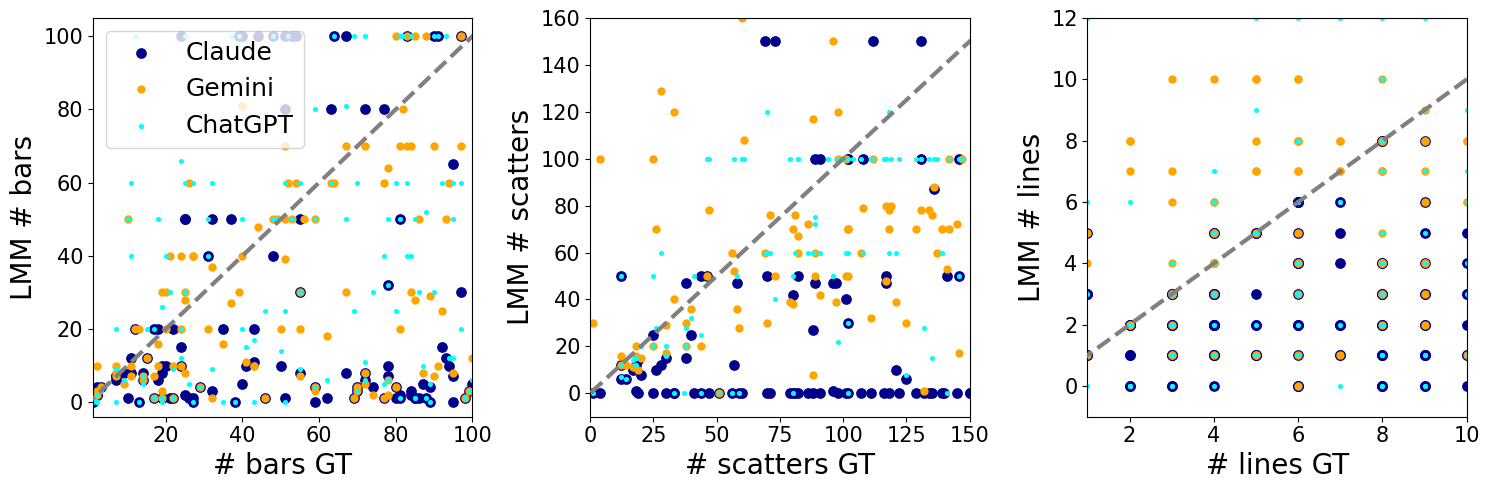

In [20]:
# by number of item
questions_figure = [
    {'tag':'# bars', 'question':'How many bars are there in the specified figure panel?', 'type':'float', 'yfudge':5},
    {'tag':'# scatters', 'question':'How many scatter points are there in the specified figure panel?', 
     'type':'float', 'yfudge':10, 'xlim':(0,150)},
    {'tag':'# lines', 'question':'How many lines are there in the specified figure panel?', 'type':'float', 'yfudge':2},
]

df_P_L1_question_tags = track_questions(questions_figure, df, ignore_special=True)

base = 5
nx = 1; ny = 3
npanels = nx*ny
fig, axes = plt.subplots(1,npanels, figsize=(base*npanels,base))


fontsize = 20
tick_fontsize = 15
legend_fontsize = 18

eq_linethick = 3
eq_linestyle = '--'
eq_linecolor = 'gray'

marker_sizes = {'claude':45, 'gemini_1.5':25, 'chatgpt':7}
colors = {'claude':'darkblue', 'gemini_1.5':'orange', 'chatgpt':'cyan'}
labels = {'claude':'Claude', 'gemini_1.5':'Gemini', 'chatgpt':'ChatGPT'}
ylims = {'# bars': (-100,100), '# scatters':(-100,100), '# lines':(-10,10)}

iqset = 0
plot_diffs = False
# iqset = 2
# plot_diffs = True
# normalize_diff = True

for iq,q in enumerate(questions_figure):
    dfsub = df[df['question']==q['question']]
    for imodel, model in enumerate(dfsub['model'].unique()):
        dfsub2 = dfsub[dfsub['model']==model]
        gt, lmm1 = get_lmm_gt(dfsub2, q['type'])
        gttag = q['tag']+' GT'
        lmtag = labels[model]
        if plot_diffs:
            lmm = (lmm1-gt)
            if normalize_diff:
                lmm = lmm/gt
        else:
            lmm = deepcopy(lmm1)
        dfplot = pd.DataFrame({gttag:gt, lmtag:lmm})
        if iq == iqset:
            dfplot.plot(x=gttag, y = lmtag, kind='scatter', ax=axes[iq], 
                        s=marker_sizes[model], color=colors[model], label=labels[model])
        else:
            dfplot.plot(x=gttag, y = lmtag, kind='scatter', ax=axes[iq], 
                        s=marker_sizes[model], color=colors[model])
    axes[iq].set_xlabel(gttag, fontsize=fontsize)
    if not plot_diffs:
        axes[iq].plot([np.min(gt)-q['yfudge']-10, np.max(gt)+q['yfudge']+10], 
                      [np.min(gt)-q['yfudge']-10, np.max(gt)+q['yfudge']+10], 
                      linestyle=eq_linestyle, linewidth=eq_linethick, zorder=10, 
                      color=eq_linecolor)
        axes[iq].set_ylabel('LMM ' + q['tag'], fontsize=fontsize)
        axes[iq].set_ylim(np.min(gt)-q['yfudge'], np.max(gt)+q['yfudge'])
        axes[iq].set_xlim(np.min(gt), np.max(gt))

    else:
        div = ''
        if normalize_diff: 
            div = '/GT'
            axes[iq].set_ylim(-5, 5)
        else:
            axes[iq].set_ylim(ylims[q['tag']])
        axes[iq].set_ylabel('(LMM-GT)' +div+ ' ' + q['tag'], fontsize=fontsize)
        #axes[iq].set_ylim(-q['yfudge'], q['yfudge'])
    if 'xlim' in q:
        axes[iq].set_xlim(q['xlim'])
        if not plot_diffs:
            axes[iq].set_ylim([q['xlim'][0]-q['yfudge'], q['xlim'][1]+q['yfudge']])


# set font sizes
for ax in axes:
    # Set tick label font sizes for second subplot
    ax.tick_params(axis='both', which='major', labelsize=tick_fontsize)
    legend = ax.get_legend()
    if legend is not None:
        # Set legend font size for second subplot
        ax.legend(fontsize=legend_fontsize)

fig.tight_layout()

divT = ''
if not plot_diffs:
    divT = '_notDiv'
fig.savefig(save_fig_dir + 'plotLevel_L1_numberOfElements'+divT+'.pdf')
plt.show()


In [ ]:
#lmm1-gt

array([14., -3., 57.,  0.,  1., 14., 23., -5.,  0., -7., -5., -1.,  2.,
        0., -1., -2.,  0., -4., -4., -7.,  3., -2.,  2., -5., nan, -2.,
       -2., -3., 46.,  0.,  0.,  0., -4., 14.,  0.,  0., 31., -3., -1.,
        0.,  0.,  1., 11., 46.,  0., -1.,  0.,  4., -3.,  4., 43., -2.,
       -5., 14., -3., -1.,  8.,  4., -3., 17., -3., -8.,  0.,  0., -9.,
       -1.,  2.,  0., -4., -2., -6., -6., -4., -2., -1., -9.,  7.,  0.,
       nan, -3.,  2., 11., -5., -1.,  0.,  2.,  2.,  5., -2., 55.,  5.,
        0., -3., 21.,  5.,  2., -3., -2.,  0., 21., 15., -1., -8.,  0.,
       -2.,  6., -8., -8., -9., -4.,  0., -6., -4., 21.,  3., 13., -7.,
       -7.])

In [ ]:
#gt-lmm

array([-14.,   3., -57.,   0.,  -1., -14., -23.,   5.,   0.,   7.,   5.,
         1.,  -2.,   0.,   1.,   2.,   0.,   4.,   4.,   7.,  -3.,   2.,
        -2.,   5.,  nan,   2.,   2.,   3., -46.,   0.,   0.,   0.,   4.,
       -14.,   0.,   0., -31.,   3.,   1.,   0.,   0.,  -1., -11., -46.,
         0.,   1.,   0.,  -4.,   3.,  -4., -43.,   2.,   5., -14.,   3.,
         1.,  -8.,  -4.,   3., -17.,   3.,   8.,   0.,   0.,   9.,   1.,
        -2.,   0.,   4.,   2.,   6.,   6.,   4.,   2.,   1.,   9.,  -7.,
         0.,  nan,   3.,  -2., -11.,   5.,   1.,   0.,  -2.,  -2.,  -5.,
         2., -55.,  -5.,   0.,   3., -21.,  -5.,  -2.,   3.,   2.,   0.,
       -21., -15.,   1.,   8.,   0.,   2.,  -6.,   8.,   8.,   9.,   4.,
         0.,   6.,   4., -21.,  -3., -13.,   7.,   7.])

(0.0, 10.0)

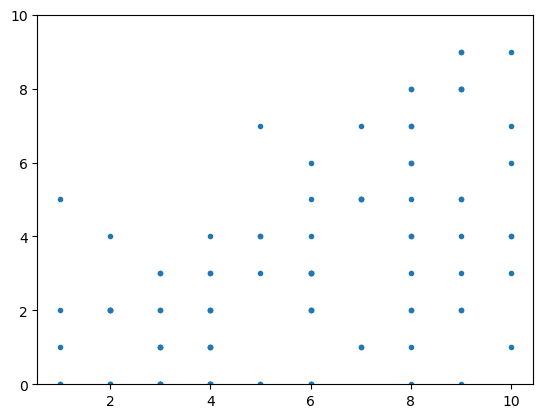

In [ ]:
# plt.plot(gt, np.abs(gt-lmm), '.')
# plt.ylim(0,10)

In [24]:
len(dfsub[dfsub['model']=='claude']), len(dfsub[dfsub['model']=='chatgpt']), len(dfsub[dfsub['model']=='gemini_1.5'])

(118, 118, 118)

In [25]:
dfsub

,image id,plot number,plot type,question,use list,model,model id,LMM Answer,GT Answer,Level,Level Type
13,Picture149,0.0,line,How many lines are there in the specified figu...,False,claude,claude-sonnet-4-20250514,{'nlines': 1},{'nlines': 6},Level 1,Plot-level questions
67,Picture185,4.0,line,How many lines are there in the specified figu...,False,claude,claude-sonnet-4-20250514,{'nlines': 0},{'nlines': 3},Level 1,Plot-level questions
115,Picture68,0.0,line,How many lines are there in the specified figu...,False,claude,claude-sonnet-4-20250514,{'nlines': 0},{'nlines': 3},Level 1,Plot-level questions
153,Picture104,0.0,line,How many lines are there in the specified figu...,False,claude,claude-sonnet-4-20250514,{'nlines': 5},{'nlines': 6},Level 1,Plot-level questions
174,Picture87,0.0,line,How many lines are there in the specified figu...,False,claude,claude-sonnet-4-20250514,{'nlines': 3},{'nlines': 3},Level 1,Plot-level questions
...,...,...,...,...,...,...,...,...,...,...,...
15057,Picture107,0.0,line,How many lines are there in the specified figu...,False,chatgpt,gpt-5-nano-2025-08-07,{'nlines': 30},{'nlines': 9},Level 1,Plot-level questions
15086,Picture53,1.0,line,How many lines are there in the specified figu...,False,chatgpt,gpt-5-nano-2025-08-07,{'nlines': 12},{'nlines': 9},Level 1,Plot-level questions
15117,Picture138,0.0,line,How many lines are there in the specified figu...,False,chatgpt,gpt-5-nano-2025-08-07,{'nlines': 20},{'nlines': 7},Level 1,Plot-level questions
15139,Picture121,1.0,line,How many lines are there in the specified figu...,False,chatgpt,gpt-5-nano-2025-08-07,{'nlines': 1},{'nlines': 8},Level 1,Plot-level questions


In [26]:
# for k,v in dfplot.items():
#     print(k, len(v))

## Questions we want to put in question table, but are not plotting!

In [27]:
df[(df['Level Type']=='Plot-level questions') & (df['Level'] == 'Level 2')]['question'].unique()

array(['What is the mean value of the data in this figure panel? ',
       'What is the mean value of the data along the color-axis in this figure panel? ',
       'What is the mean value of the data along the x-axis in this figure panel? ',
       'What is the mean value of the data along the y-axis in this figure panel? ',
       'What is the median value of the data in this figure panel? ',
       'What is the median value of the data along the color-axis in this figure panel? ',
       'What is the median value of the data along the x-axis in this figure panel? ',
       'What is the median value of the data along the y-axis in this figure panel? ',
       'Are there error bars on the data along the x-axis in this figure panel?',
       'Are there error bars on the data along the y-axis in this figure panel?'],
      dtype=object)

In [28]:
# Level 3
df[(df['Level Type']=='Plot-level questions') & (df['Level'] == 'Level 3')]['question'].unique()

array(['What is the underlying distribution used to create the data in this figure panel?',
       'What is the underlying distribution used to create the data in this figure panel along the color-axis?',
       'What is the underlying distribution used to create the data in this figure panel in the x/y-plane?',
       'What is the functional relationship between the x and y values in this figure panel?'],
      dtype=object)

In [29]:
qs_to_list1 = [
    'What are the matplotlib linestyles in this figure panel?', 
                     'Are there error bars on the data along the x-axis in this figure panel?',
       'Are there error bars on the data along the y-axis in this figure panel?',
       'What is the mean value of the data along the color-axis in this figure panel? ',
       'What is the mean value of the data along the x-axis in this figure panel? ',
       'What is the mean value of the data along the y-axis in this figure panel? ',
       'What is the median value of the data along the color-axis in this figure panel? ',
       'What is the median value of the data along the x-axis in this figure panel? ',
       'What is the median value of the data along the y-axis in this figure panel? ',
       'What is the underlying distribution used to create the data in this figure panel along the color-axis?',
       'What is the underlying distribution used to create the data in this figure panel in the x/y-plane?',
       'What is the functional relationship between the x and y values in this figure panel?'
]

qs_to_list = []
for q in qs_to_list1:
    qs_to_list.append({'tag':' ', 'question':q, 'type':'NOT SPECIAL'})

df_questions_not_asked = track_questions(qs_to_list, df, ignore_special=True)


In [30]:
df_questions_not_asked

{'tag': [' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' ', ' '],
 'question': ['What are the matplotlib linestyles in this figure panel?',
  'Are there error bars on the data along the x-axis in this figure panel?',
  'Are there error bars on the data along the y-axis in this figure panel?',
  'What is the mean value of the data along the color-axis in this figure panel? ',
  'What is the mean value of the data along the x-axis in this figure panel? ',
  'What is the mean value of the data along the y-axis in this figure panel? ',
  'What is the median value of the data along the color-axis in this figure panel? ',
  'What is the median value of the data along the x-axis in this figure panel? ',
  'What is the median value of the data along the y-axis in this figure panel? ',
  'What is the underlying distribution used to create the data in this figure panel along the color-axis?',
  'What is the underlying distribution used to create the data in this figure panel in the x/y-plane

## Question Types

At the end, put togehter all uestion types

In [31]:
from utils.latex_utils import table_iConf_format

In [32]:
df_question_table = pd.DataFrame(df_question_tags)

for d in [df_F_question_tags, df_P_L1_question_tags, df_questions_not_asked]:
    d2 = pd.DataFrame(d)
    df_question_table = pd.concat([df_question_table, d2])

In [33]:
df_question_table

,tag,question,Level,Type
0,\# panels,How many panels are in this figure?,1,Figure
1,plot type,What is the plot style used in this figure?,1,Figure
2,colormap,What is the colormap that was used in this fig...,1,Figure
3,titles,What are the titles for each figure panel?,1,Figure
0,\# bars,How many bars are there in the specified figur...,1,Plot
1,\# scatters,How many scatter points are there in the speci...,1,Plot
2,\# lines,How many lines are there in the specified figu...,1,Plot
0,,What are the matplotlib linestyles in this fig...,1,Plot
1,,Are there error bars on the data along the x-a...,2,Plot
2,,Are there error bars on the data along the y-a...,2,Plot


In [34]:
label='tab:question_map'
caption = 'Questions and tags.  '
caption += '\\rt{so here I think we wanna list at least all questions but maybe not all tags? only tags if refernced in other tables? or just dont put them in here if not used?}'

column_format_tag = '|'
for c in df_question_table.columns:
    column_format_tag += 'l|'

latex_table_tag = table_iConf_format(df_question_table, label, caption, column_format_tag)

print(latex_table_tag)

\begin{table}[h!]
\begin{tabular}{|l|l|l|l|}
\hline
\rowcolor{black}
\color{white} tag & \color{white} question & \color{white} Level & \color{white} Type \\ 
\hline
\# panels & How many panels are in this figure? & 1 & Figure \\ \hline
plot type & What is the plot style used in this figure? & 1 & Figure \\ \hline
colormap & What is the colormap that was used in this figure? & 1 & Figure \\ \hline
titles & What are the titles for each figure panel? & 1 & Figure \\ \hline
\# bars & How many bars are there in the specified figure panel? & 1 & Plot \\ \hline
\# scatters & How many scatter points are there in the specified figure panel? & 1 & Plot \\ \hline
\# lines & How many lines are there in the specified figure panel? & 1 & Plot \\ \hline
  & What are the matplotlib linestyles in this figure panel? & 1 & Plot \\ \hline
  & Are there error bars on the data along the x-axis in this figure panel? & 2 & Plot \\ \hline
  & Are there error bars on the data along the y-axis in this figure pa